Key for what you need to run vs. understand. Each section will be different:

§ = run the code and look at the output. Does what you are seeing make sense?
- what is the data type?
- what does it represent?
- what manipulation was made to get to this point?

ø = just run the code, no need to understand it
- after class, you can come back and look at the code line by line

! = understand each line of the code
- if we are calling a function, what is it doing? What do the arguments and parameters mean?

¡ = you change the code
- there may be a template or skeleton code
- you can change the code, add cells, explore objects
- make sure you know each step of what you are doing
    - what are the functions doing?
    - what are the object's data type?
    - if it is a matrix or array, what is the shape? what are the rows and columns?

# Import Libraries and Objects

## ø Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

In [54]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn import preprocessing

In [55]:
from IPython.display import Image
import urllib.request
import pickle
    
    
def load_object(filename):
    #loads .pkl object from URL
    with urllib.request.urlopen(filename) as response:
        return pickle.load(response)

These are the folders where the items are located. We will use these strings later, when we choose to load in the objects.

## ø Set filepaths

In [56]:
home_path = "https://raw.githubusercontent.com/Ishihara-SynthMorph/CompBioHA_IntroProgramming/refs/heads/main/Lecture2_RNAseq"

files_dict = {}

for f in ["test_labels", "test_counts", "probe_genes"]:
    files_dict[f] = os.path.join(home_path, "Data", f) + ".csv"
    
for f in ["clustered_heatmap", "complete_heatmap"]:
    files_dict[f] = os.path.join(home_path, "Figures", f) + ".png"
    
models = ['PCA', 'SVM_20-random_scaled-counts', 'SVM_200-random_scaled-counts', 
'SVM_2k-random_scaled-counts', 'SVM_all_pca', 'SVM_all_scaled-counts', 'SVM_all_unscaled-counts', 
'SVM_bottom500_pca', 'SVM_bottom5_pca', 'SVM_top5_pca', 'hints', 'scaler']
for f in models:
    files_dict[f] = os.path.join(home_path, "Models", f) + ".pkl"

## ! Import Data

In [57]:
test_counts = pd.read_csv(files_dict["test_counts"], index_col=0)
test_labels = pd.read_csv(files_dict["test_labels"], index_col=0)
probe_genes = pd.read_csv(files_dict["probe_genes"])

hints = load_object(files_dict["hints"])
scaler = load_object(files_dict["scaler"])
pca = load_object(files_dict["PCA"])

These files contain the following information:
- test_labels is a table with the Sample #s as rows, and one column containing the Tumor Class
    - the Tumor "Class" is encoded as a string. There are 5 different classes.
- test_counts is a table with the Sample #s as rows and many columns containing gene counts data
    - the counts data is encoded as a number
    - the data is log-normalized, meaning that:
        - it was originally whole #s representing how many RNA molecules were counted for a given gene in a given sample
        - if you are interested, you can view these resources about why log-transformation is commonly done:
            - https://informatics.fas.harvard.edu/resources/tutorials/differential-expression-analysis/
            - https://www.nature.com/articles/s41592-023-01814-1
            - https://seqqc.wordpress.com/2015/02/16/should-you-transform-rna-seq-data-log-vst-voom/comment-page-1/
    - the column names are listed as "gene_#"
- probe_genes contains a list of strings separated by line
    - each of these strings corresponds to the name of a gene
    - it is the same length as the # of columns in test_counts, since each gene name corresponds to a gene #
    - therefore we will use it to set the column names in the dataframes we use 

# Wrangle Data

## ! Use .shape and .head to explore the data

In [58]:
print(f"Shape of labels: {test_labels.shape}")
test_labels.head()

Shape of labels: (241, 1)


,Class
sample_698,KIRC
sample_498,BRCA
sample_278,KIRC
sample_619,BRCA
sample_353,COAD


In [59]:
print(f"Shape of counts: {test_counts.shape}")
test_counts.head()

Shape of counts: (241, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_698,0.807767,1.909965,2.857523,6.486339,8.882395,0.0,7.339636,0.000000,0.0,0.0,...,6.297806,8.328451,10.161724,2.358284,10.034318,11.927059,10.504233,9.646334,6.175816,0.000000
sample_498,0.000000,3.943528,4.488059,7.116614,9.352608,0.0,8.742023,1.909159,0.0,0.0,...,6.167239,9.332486,10.307816,4.476369,9.428756,12.321677,10.918013,9.390339,6.635540,0.000000
sample_278,0.000000,2.428518,2.793542,6.855118,9.075821,0.0,5.676493,0.000000,0.0,0.0,...,6.592299,8.554589,10.449964,3.372534,10.492154,11.896764,10.232733,9.797136,5.199617,0.000000
sample_619,0.000000,2.943190,1.395063,5.707174,9.559937,0.0,7.858186,0.984772,0.0,0.0,...,6.469500,9.902295,10.220221,5.981019,10.026662,11.167155,10.615887,10.741644,7.795994,0.574828
sample_353,0.000000,3.006388,3.594023,7.673132,9.559761,0.0,8.405456,0.550310,0.0,0.0,...,5.553800,8.764002,9.789092,1.920789,9.279427,12.118331,10.956507,8.974423,2.814961,0.550310


In [60]:
print(f"Shape of gene list {probe_genes.shape}")
probe_genes[5000:5010]

Shape of gene list (20531, 1)


,gene
5000,DLGAP3
5001,DLGAP4
5002,DLGAP5
5003,DLK1
5004,DLK2
5005,DLL1
5006,DLL3
5007,DLL4
5008,DLST
5009,DLX1


## § Add the tumor class and gene names

In [61]:
#gene names have one duplicate
#remove duplicates in a very clunky manner. there is only one duplicate
while probe_genes.duplicated().value_counts()[False] != len(probe_genes):
    probe_genes[probe_genes.duplicated()]  = probe_genes[probe_genes.duplicated()] + "_duplicated"

In [62]:
test = test_counts #just a shorter name that is easier to use

In [63]:
#let's use the gene names and add them as the column names for the data
test.columns = probe_genes["gene"].to_list()

In [64]:
test.iloc[1:10, 11000:11005].head()

,MLYCD,MMAA,MMAB,MMACHC,MMADHC
sample_498,7.496079,7.971544,8.482578,6.420309,10.430588
sample_278,8.161228,9.258151,8.956873,6.754968,10.628928
sample_619,8.161711,8.286821,9.062124,7.114190,11.148299
sample_353,9.045880,8.115356,10.118098,6.997496,10.236122
sample_775,7.477475,7.751705,8.567629,6.841747,10.524884


In [65]:
#These genes are all in alphabetical order. We can also query specific genes:
test[["BRCA1", "BRCA2"]].head()

,BRCA1,BRCA2
sample_698,7.027419,6.697857
sample_498,8.164037,7.104483
sample_278,7.476244,6.492037
sample_619,8.584064,6.958239
sample_353,10.124716,8.844910


In [66]:
#lets also make a dataframe which contains the Class data. this will be useful for plotting later!
test_byclass = test.copy()
test_byclass.index = test_labels["Class"]
#and then sort by index so that all of the tumor classes apear together
test_byclass = test_byclass.sort_values("Class")

In [67]:
test_byclass.head()

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Class,,,,,,,,,,,,,,,,,,,,,
BRCA,0.0,4.388382,3.528571,6.962989,9.731032,0.0,6.632124,0.370834,0.0,0.0,...,4.921746,8.094310,9.518592,7.968275,9.409654,11.747085,9.959708,10.234554,3.334311,0.000000
BRCA,0.0,3.805664,2.398405,7.172468,10.311078,0.0,7.987059,0.354226,0.0,0.0,...,5.586041,8.695514,10.467014,8.236416,9.767953,11.628213,10.033478,10.003279,4.432665,0.354226
BRCA,0.0,2.262283,3.266966,6.267555,10.363127,0.0,7.665982,0.499884,0.0,0.0,...,6.053789,9.348726,9.982808,6.987469,9.336763,10.843301,10.443410,11.703510,3.654825,0.000000
BRCA,0.0,2.159758,1.995593,6.758210,9.805471,0.0,6.254042,0.442227,0.0,0.0,...,5.961954,9.772719,9.950066,4.470023,9.781565,12.020588,9.880402,9.601446,7.570038,0.000000
BRCA,0.0,1.069358,3.920188,5.796725,9.736196,0.0,7.867025,0.000000,0.0,0.0,...,5.130041,7.755529,10.015443,4.992279,8.177160,12.343846,10.400303,8.123175,7.970526,0.000000


To summarize, we have combined the following data:
- counts matrix for each sample
- tumor "Class" metadata for each sample
- gene names

Into two dataframes:
- "train"
    -this has Sample # on as rows and Gene Name as columns
- "train_byclass"
    -this has Class (tumor type) as rows and Gene Name as columns
    
Both will be useful for visualizations and making our classifier.

# Exploring the Data

## § One gene's Counts data

Lets focus on one gene of interest. you can choose one from the list:
- BRCA1

In [171]:
#Gene of Interest [GOI]
goi = "BRCA1"

### § What is the distribution of the counts? Let's plot a histogram

In [69]:
#First, let's pull out the data from the dataframe
x = test[goi]
x

sample_698     7.027419
sample_498     8.164037
sample_278     7.476244
sample_619     8.584064
sample_353    10.124716
                ...    
sample_137     7.844279
sample_57     10.218769
sample_403     8.222317
sample_140     8.082570
sample_660     6.396228
Name: BRCA1, Length: 241, dtype: float64

Text(0, 0.5, 'Frequency')

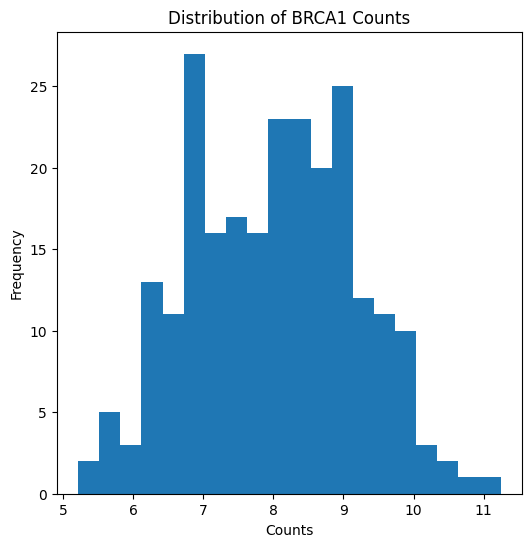

In [70]:
fig, ax = plt.subplots(figsize = (6,6))

ax.hist(x,
       bins = 20)

ax.set_title(f"Distribution of {goi} Counts")
ax.set_xlabel("Counts")
ax.set_ylabel("Frequency")

## § Let's look at the individual counts in the first 20 samples

In [71]:
x = test[:20]

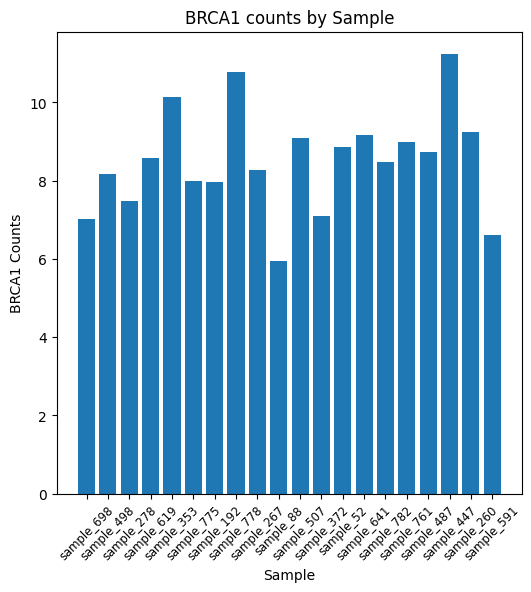

In [72]:
fig, ax = plt.subplots(figsize=(6,6))

ax.bar(x.index, height = x[goi])

ax.set_title(f"{goi} counts by Sample")
ax.set_xlabel("Sample")
ax.set_ylabel(f"{goi} Counts")

ax.tick_params("x", rotation=45, labelsize = "small")

### § Do the tumor Classes have different expression of this gene?

Text(0, 0.5, 'mean BRCA1 Counts')

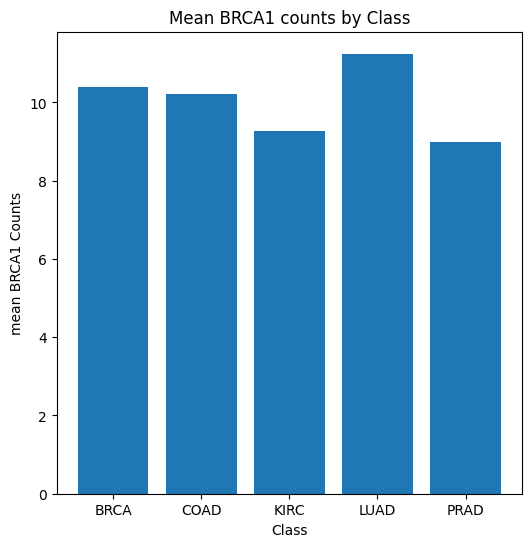

In [73]:
fig, ax = plt.subplots(figsize=(6,6))

ax.bar(test_byclass.index, height = test_byclass[goi])

ax.set_title(f"Mean {goi} counts by Class")
ax.set_xlabel("Class")
ax.set_ylabel(f"mean {goi} Counts")

This tells us the mean counts, but it isn't really informative. Let's dive a little bit deeper and look at the distribution as well as the mean

In [74]:
#first we need a list of all of the tumor types that are here
classes = list(set(test_labels["Class"].to_list()))
classes

['LUAD', 'BRCA', 'PRAD', 'COAD', 'KIRC']

Text(0.5, 0.98, 'Distribution of BRCA1 by Class')

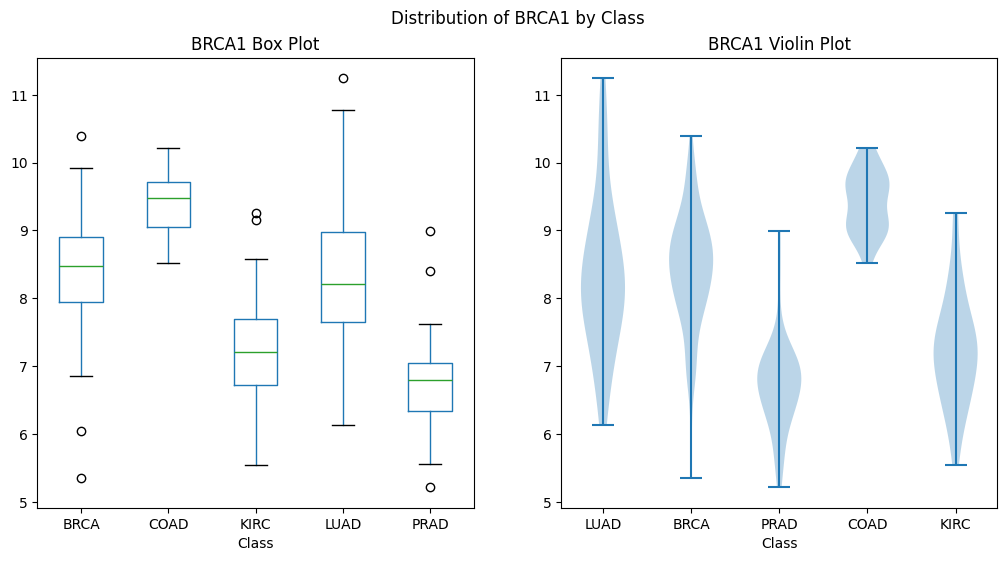

In [75]:
fig, (ax_box, ax_vln) = plt.subplots(ncols=2, figsize=(12,6))

#boxplot is a Pandas function that can be run on the Dataframe and pointed to the matplotlib "axes" object
test_byclass.boxplot(by = "Class", column =[goi], 
                               grid = False,
                              ax=ax_box)
ax_box.set_title(f"{goi} Box Plot")

#for the violin plot, we need to make list of arrays
#the list will have 5 arrays (one for each Class), each containing the counts for our Gene of Interest
dataset = [test_byclass[test_byclass.index == c][goi].values for c in classes]
ax_vln.violinplot(
    dataset=dataset
)

ax_vln.set_title(f"{goi} Violin Plot")
ax_vln.set_xlabel("Class")
ax_vln.set_xticks(ticks = list(np.arange(1,(len(classes) + 1))), labels = classes)




fig.suptitle(f"Distribution of {goi} by Class")

## § Looking at 2 genes

In [76]:
def plot_2_genes(counts_df, gene1, gene2):
    df = counts_df.copy() #make sure not to change the original
    
    fig, ax = plt.subplots()
    
    #get all of the metadata categories to plot
    classes = list(set(df.index))
    for c in classes:
        x = df.loc[c][gene1]
        y = df.loc[c][gene2]
        ax.scatter(x, y, label = c)
        
    ax.legend()
    ax.set_title(f"{gene1} and {gene2} by Class")
    ax.set_xlabel(gene1)
    ax.set_ylabel(gene2)

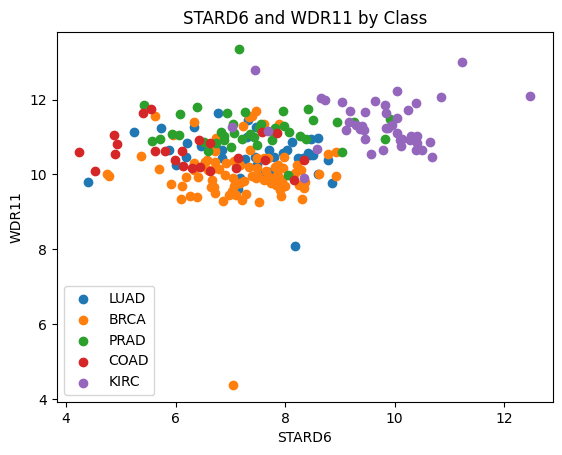

In [77]:
plot_2_genes(test_byclass, "STARD6", "WDR11")

## § Looking at multiple genes

### ø Building Intuition for a Heatmap

In [78]:
n_samples = 20
n_genes = 20
df = test.iloc[1:n_samples,1:n_genes].copy()
#let's grab a small subset of the data to visualize

In [79]:
#we have to pick a new gene
ex_gene = df.columns[1] #just pick one that isn't all zeros

Text(0.5, 0, 'Counts')

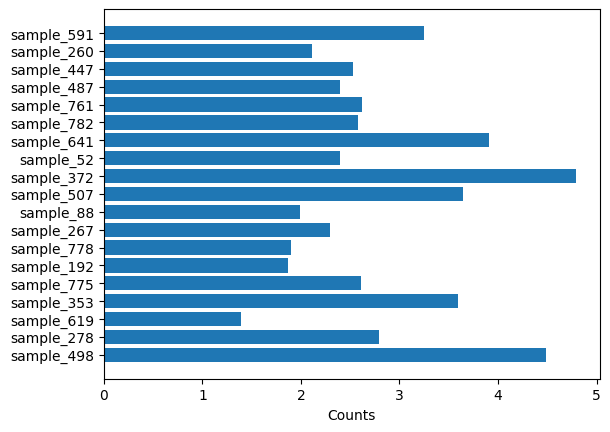

In [80]:
fig, ax = plt.subplots()

bars = ax.barh(df.index, df[ex_gene])
ax.set_xlabel("Counts")

/scratch/slurm-10283637/ipykernel_2132629/3543478424.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'


Text(0.5, 0, 'Gene Counts')

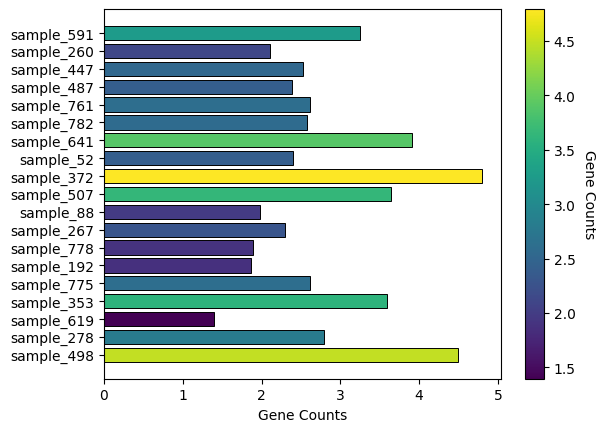

In [81]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots()

#Create a normalization object to map data to the 0-1 range
norm = mcolors.Normalize(vmin=min(df[ex_gene]), vmax=max(df[ex_gene]))

#Choose a colormap and apply the normalized values to get colors
cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'
bar_colors = cmap(norm(df[ex_gene]))

#Plot the bars with the ex_gene counts encoded as both height and colors
bars = ax.barh(df.index, df[ex_gene], color=bar_colors, edgecolor='black', linewidth=0.7)

# Add a colorbar legend to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Gene Counts', rotation=270, labelpad=15)

ax.set_xlabel("Gene Counts")

Here, both the height and the color are representing the gene counts

/scratch/slurm-10283637/ipykernel_2132629/1653304214.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'


Text(0.5, 0, 'Gene Counts')

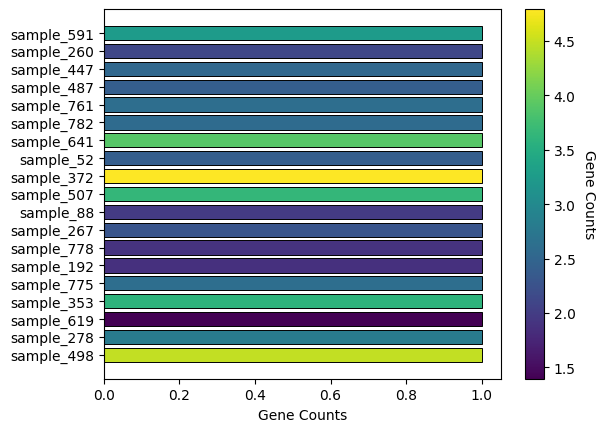

In [82]:
fig, ax = plt.subplots()

#Create a normalization object to map data to the 0-1 range
norm = mcolors.Normalize(vmin=min(df[ex_gene]), vmax=max(df[ex_gene]))

#Choose a colormap and apply the normalized values to get colors
cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'
bar_colors = cmap(norm(df[ex_gene]))

#Plot the bars with the ex_gene counts encoded as both height and colors
bars = ax.barh(df.index, width=1, color=bar_colors, edgecolor='black', linewidth=0.7)

# Add a colorbar legend to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Gene Counts', rotation=270, labelpad=15)

ax.set_xlabel("Gene Counts")

<Axes: >

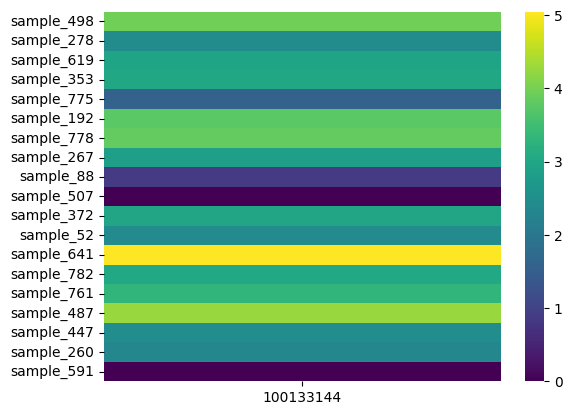

In [83]:
sns.heatmap(df.iloc[:,0:1], cmap="viridis")

<Axes: >

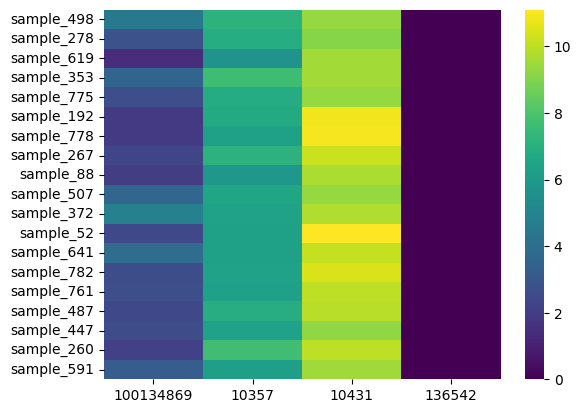

In [84]:
sns.heatmap(df.iloc[:,1:5], cmap="viridis")

<Axes: >

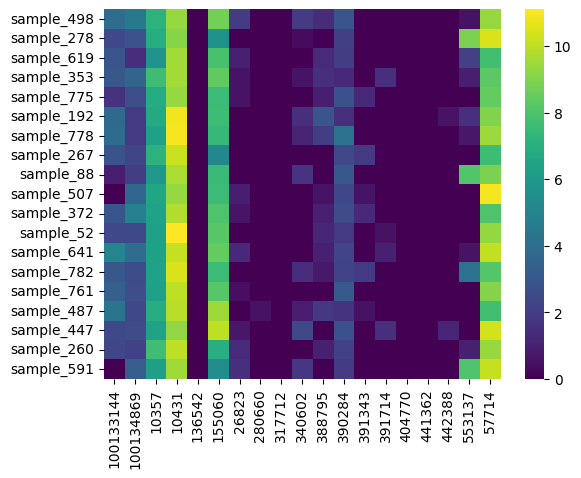

In [85]:
sns.heatmap(df, cmap="viridis")

<Axes: >

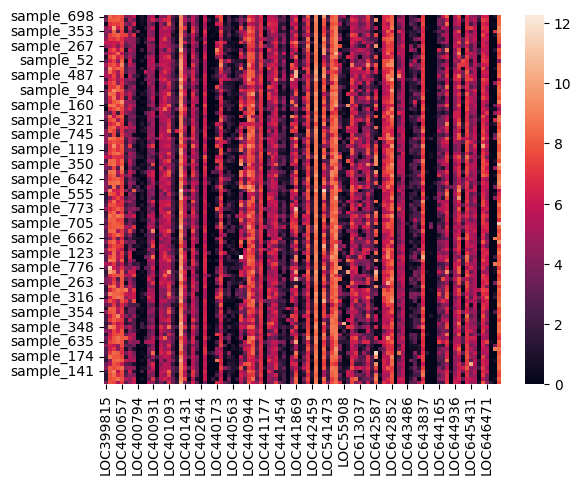

In [86]:
sns.heatmap(test.iloc[:100, 10000:10100])

## § Heatmaps

NOTE: !!!!
This code may will take a long time to run. Therefore it is commented.

You can just look at the saved images.

In [87]:
# heatmap = sns.heatmap(test_byclass)
# plt.savefig("Figures/complete_heatmap.png")

Image(url=files_dict["complete_heatmap"], width=1000, height=1000)

### § Clustered Heatmaps

In [88]:
# clustgrid = sns.clustermap(test_byclass)
# plt.savefig("Figures/clustered_heatmap.png")

Image(url=files_dict["clustered_heatmap"], width=1000, height=1000)

# Dimensional Reduction with PCA

## ! Feature Scaling

This step takes the log-transformed counts makes it such that the mean = 0 and the variance / standard deviation = 0.

The "scaler" is a StandardScaler object from the scikit learn library. Read more here:
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler

The scaler has already been "fit" to the testing data. We simply have to transform the test data with the same scaler.

In [89]:
test_scaled = scaler.transform(test)

print("Features standardized (mean=0, std=1)")
print(f"Training data - mean: {test_scaled.mean():.2f}, std: {test_scaled.std():.2f}")

Features standardized (mean=0, std=1)
Training data - mean: 0.01, std: 1.05


## ! Import the PCA and transform the data with it

We have to import the PCA object. Similarly to the scaler object, this is a class from sci-kit learn and has been fit to the training data. Therefore we want to apply the same manipulation to our testing data.
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA

In [90]:
n_samples, n_features = test_scaled.shape
print(f"number of samples: {n_samples}")
print(f"number of features: {n_features}")

number of samples: 241
number of features: 20531


In [91]:
test_pca = pca.transform(test_scaled)

In [92]:
print(type(test_pca))
print(test_pca.shape)
test_pca[:10][:10]

<class 'numpy.ndarray'>
(241, 559)


array([[ 88.68444004,  18.2819582 , -13.45063955, ...,   0.18421614,
          0.15608599,   0.44655302],
       [ 18.87023269, -13.72204945,   4.16900608, ...,  -1.35854682,
         -0.5305393 ,  -1.33821148],
       [103.5119958 ,  -3.44474962,  -6.54826068, ...,   0.81683754,
          1.48725906,  -0.39069308],
       ...,
       [-37.04579959,  14.3801983 , -43.50981282, ...,   0.41139833,
          0.69965983,   1.32839202],
       [-50.93422967, -32.7213312 , -53.99456817, ...,  -0.98258943,
         -0.29462758,   0.14576693],
       [ 74.77251944,  75.81483946,   5.06988677, ...,  -0.47002417,
          0.69532916,   0.57260915]])

In [93]:
# For easier manipulation, let's make this into a pandas dataframe
# and also label the rows (sampels) and columns (Principal Components or PCs)
pca_df = pd.DataFrame(test_pca)

#add the sample names
pca_df["Sample"] = test_labels.index
pca_df.set_index("Sample", inplace=True)

#rename the columns
pca_df.columns = [f"PC{x + 1}" for x in list(pca_df.columns)]

#add a column for class
pca_df["Class"] = test_labels["Class"]

In [94]:
print(pca_df.shape)
pca_df.head()

(241, 560)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC551,PC552,PC553,PC554,PC555,PC556,PC557,PC558,PC559,Class
Sample,,,,,,,,,,,,,,,,,,,,,
sample_698,88.684440,18.281958,-13.450640,-3.593883,-9.200426,-3.531811,17.191465,15.601291,0.912519,-2.815283,...,0.287190,-0.803464,0.828667,-0.055452,0.364149,0.081917,0.184216,0.156086,0.446553,KIRC
sample_498,18.870233,-13.722049,4.169006,-38.613325,-15.389532,-33.768745,17.757435,19.807933,2.495846,-15.111517,...,0.061513,-1.081662,0.730093,-0.295695,0.261490,-0.051719,-1.358547,-0.530539,-1.338211,BRCA
sample_278,103.511996,-3.444750,-6.548261,23.591170,-1.420654,5.488276,-1.725163,17.154119,-12.718253,-1.954741,...,-1.356700,1.535626,-0.108306,0.254796,1.102321,-0.459322,0.816838,1.487259,-0.390693,KIRC
sample_619,-0.455809,-37.794321,28.326253,-14.147882,22.747553,-15.615900,-10.336150,-3.996724,-5.848706,-10.016908,...,-0.580587,0.740721,0.565349,0.257566,-0.500559,-0.077793,-1.149876,-1.319790,0.501143,BRCA
sample_353,-66.241762,35.079936,-54.969487,63.303215,0.249564,-48.775623,-2.371993,20.215206,6.450137,-10.877992,...,0.463251,-0.060492,-0.106721,-0.202217,-0.674877,1.148996,-0.321598,-0.534956,-1.111020,COAD


## § Visualizing PCA: variance explained

In [95]:
print(f"Variance explained by first 5 PCs:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
     print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f}")
print(f"\nCumulative variance (first 2 PCs): {pca.explained_variance_ratio_[:2].sum():.4f}")

Variance explained by first 5 PCs:
  PC1: 0.1081
  PC2: 0.0891
  PC3: 0.0784
  PC4: 0.0546
  PC5: 0.0420

Cumulative variance (first 2 PCs): 0.1971


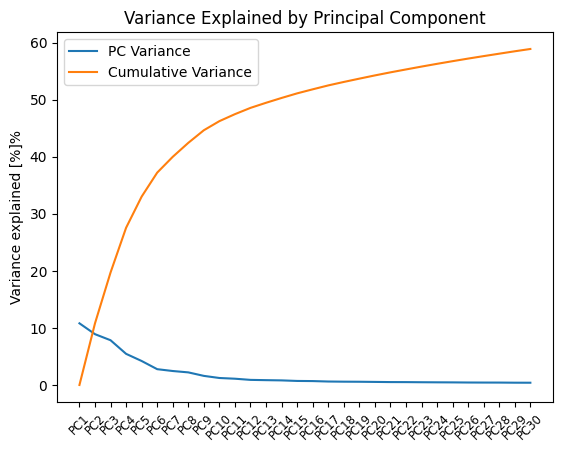

In [96]:
#plot the variance and cumulative variance of X PCs
n_PCs_plot = 30

fig, ax = plt.subplots()

PCs = list(pca_df.columns[0:n_PCs_plot])

variance = pca.explained_variance_ratio_[0:n_PCs_plot] * 100
ax.plot(PCs, variance, label="PC Variance")

cumulative = []
for i in range(n_PCs_plot):
    cumulative.append(pca.explained_variance_ratio_[:i].sum() * 100)
ax.plot(PCs, cumulative, label = "Cumulative Variance")

ax.tick_params("x", rotation=45, labelsize = "small")
ax.set_title("Variance Explained by Principal Component")
ax.set_ylabel("Variance explained [%]%")
ax.legend()

The variance explained of each PC represents how much of the spread / variance is encapsulated by that given component. The first ones explain most of the variance, while the later ones barely contribute. For this reason, many analyses only use the first X principal components.

## § Visualizing PCAs: each Component's weights

In [97]:
#The weights of each gene are stored as a numpy array:
print(pca.components_.shape)
pca.components_

(559, 20531)


array([[ 0.0004207 , -0.00285084, -0.00544713, ...,  0.00191761,
         0.00204805,  0.0005784 ],
       [ 0.00298296, -0.00555163,  0.00061467, ..., -0.01493405,
        -0.00232227,  0.00063435],
       [ 0.00056784,  0.00185128,  0.00654744, ...,  0.00234638,
         0.00661585, -0.00186223],
       ...,
       [ 0.00460814,  0.01154775, -0.01883573, ...,  0.00024985,
        -0.00230177, -0.0127985 ],
       [-0.00450643, -0.00756864, -0.00033534, ..., -0.00590954,
        -0.01910397,  0.00230145],
       [-0.01084903,  0.01444238, -0.00672296, ..., -0.00194758,
         0.00231078,  0.00480825]])

In [98]:
#let's turn that into a pandas dataframe to make it easier to access
loading = pd.DataFrame(pca.components_)

#rename the rows to be principal components
loading.index = [f"PC{x+1}" for x in list(loading.index)]

#rename the columns
loading.columns = test.columns

loading.head()

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
PC1,0.000421,-0.002851,-0.005447,-0.008545,-0.011279,2.401769e-17,-0.005589,0.002489,-0.000558,-0.000612,...,0.011813,0.001191,0.000767,-0.001912,0.012505,-0.000017,0.004627,0.001918,0.002048,0.000578
PC2,0.002983,-0.005552,0.000615,-0.001565,-0.000150,7.633926e-17,0.004348,-0.001101,0.000492,-0.000281,...,-0.009219,-0.016046,-0.006432,-0.008395,-0.011060,0.008410,-0.005281,-0.014934,-0.002322,0.000634
PC3,0.000568,0.001851,0.006547,-0.008085,-0.003594,1.075812e-16,0.006406,0.002489,-0.001186,-0.001182,...,0.005185,0.002780,0.005936,0.007403,0.003793,-0.008659,0.004589,0.002346,0.006616,-0.001862
PC4,-0.000494,0.007493,0.003898,0.009169,-0.005810,-8.068634e-17,-0.008512,0.000412,-0.001983,-0.000386,...,0.008774,0.005753,0.003459,-0.012703,0.005353,-0.008621,0.007021,0.005522,-0.010201,-0.002334
PC5,-0.001646,-0.012983,-0.015749,-0.001142,0.009221,-1.256215e-16,-0.001173,0.001311,0.001013,0.000274,...,-0.000314,0.002826,-0.003687,-0.000491,-0.004424,-0.003496,-0.009135,-0.001809,-0.003772,-0.005603


In [99]:
PC1load = loading.loc["PC1"].sort_values()
PC1load

C20orf151   -0.018488
PKP3        -0.018267
C9orf139    -0.018141
ZMYND15     -0.018015
PXT1        -0.017568
               ...   
ROR2         0.018617
GIT2         0.018739
PKD2L2       0.018752
ZDHHC9       0.018812
STARD6       0.018902
Name: PC1, Length: 20531, dtype: float64

In [100]:
def plot_PC_loadings(PC, label="PC",
                    n_genes_plot = 30):
    #first we have to sort the values of the PC
    PC = PC.copy().sort_values() #make sure not to change the original!
    
    #since we're plotting both positive and negative loadings
    n = math.ceil(n_genes_plot/2)
    
    fig, ax = plt.subplots()

    y = pd.concat([PC[:n], PC[-n:]])

    ax.barh(y.index, y.values)

    ax.set_title(f"Loadings of {label}")
    ax.set_xlabel("Loading of gene")
    ax.set_ylabel("Gene")

    ax.tick_params("y", labelsize = "small")

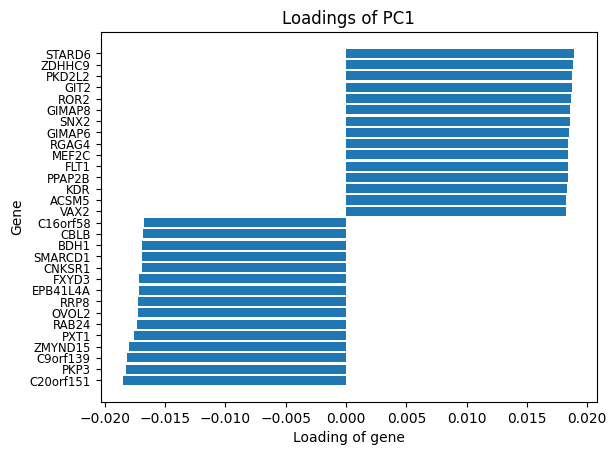

In [101]:
plot_PC_loadings(loading.loc["PC1"],
                label = "PC1")

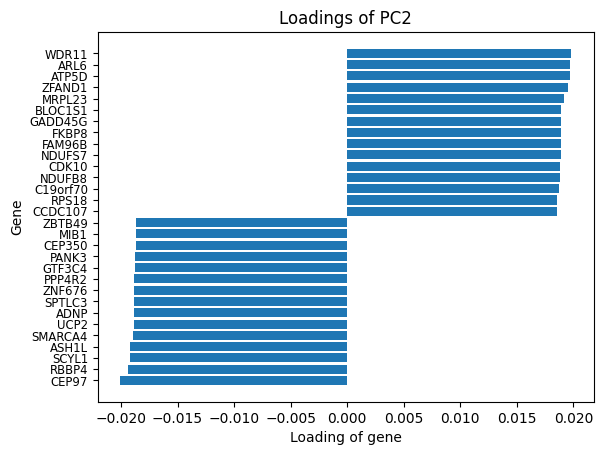

In [102]:
plot_PC_loadings(loading.loc["PC2"],
                label = "PC2")

## § Visualizing PCAs: by tumor class

In [103]:
def plot_PCs(pca_df,
            PC_x,
            PC_y):
    fig, ax = plt.subplots()
    
    #plot the five classes separately
    classes = list(set(pca_df["Class"]))
    for c in classes:
        PCx = pca_df.loc[pca_df["Class"] == c][PC_x]
        PCy = pca_df.loc[pca_df["Class"] == c][PC_y]

        ax.scatter(PCx, PCy, label = c)
        
    ax.set_title(f"{PC_x} and {PC_y} by class")
    ax.set_xlabel(PC_x)
    ax.set_ylabel(PC_y)
    ax.legend(title = "Classes")

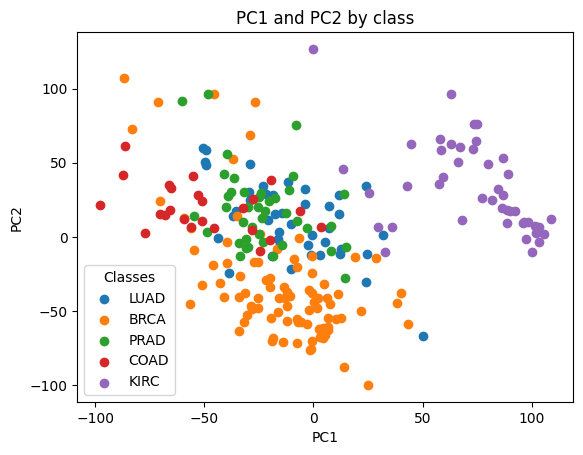

In [104]:
plot_PCs(pca_df, "PC1", "PC2")

The first 2 PCs are able to show some separates in the Classes of tumor when we label them with color.

Seaborn's Pairplot shows the same data, along with histograms of each individual component:

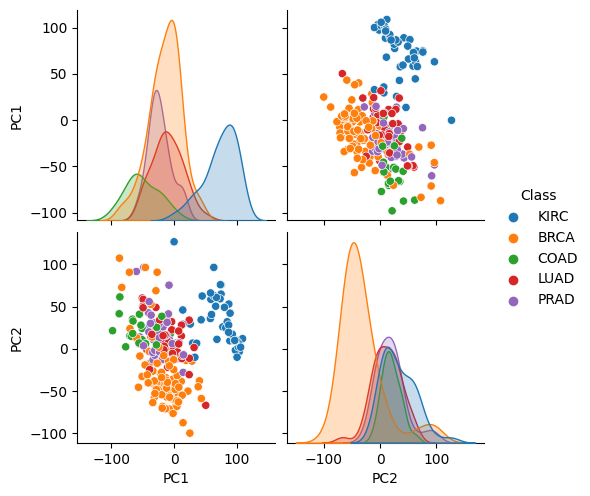

In [105]:
sns.pairplot(pca_df, 
             hue="Class",
             vars = pca_df.columns[0:2])

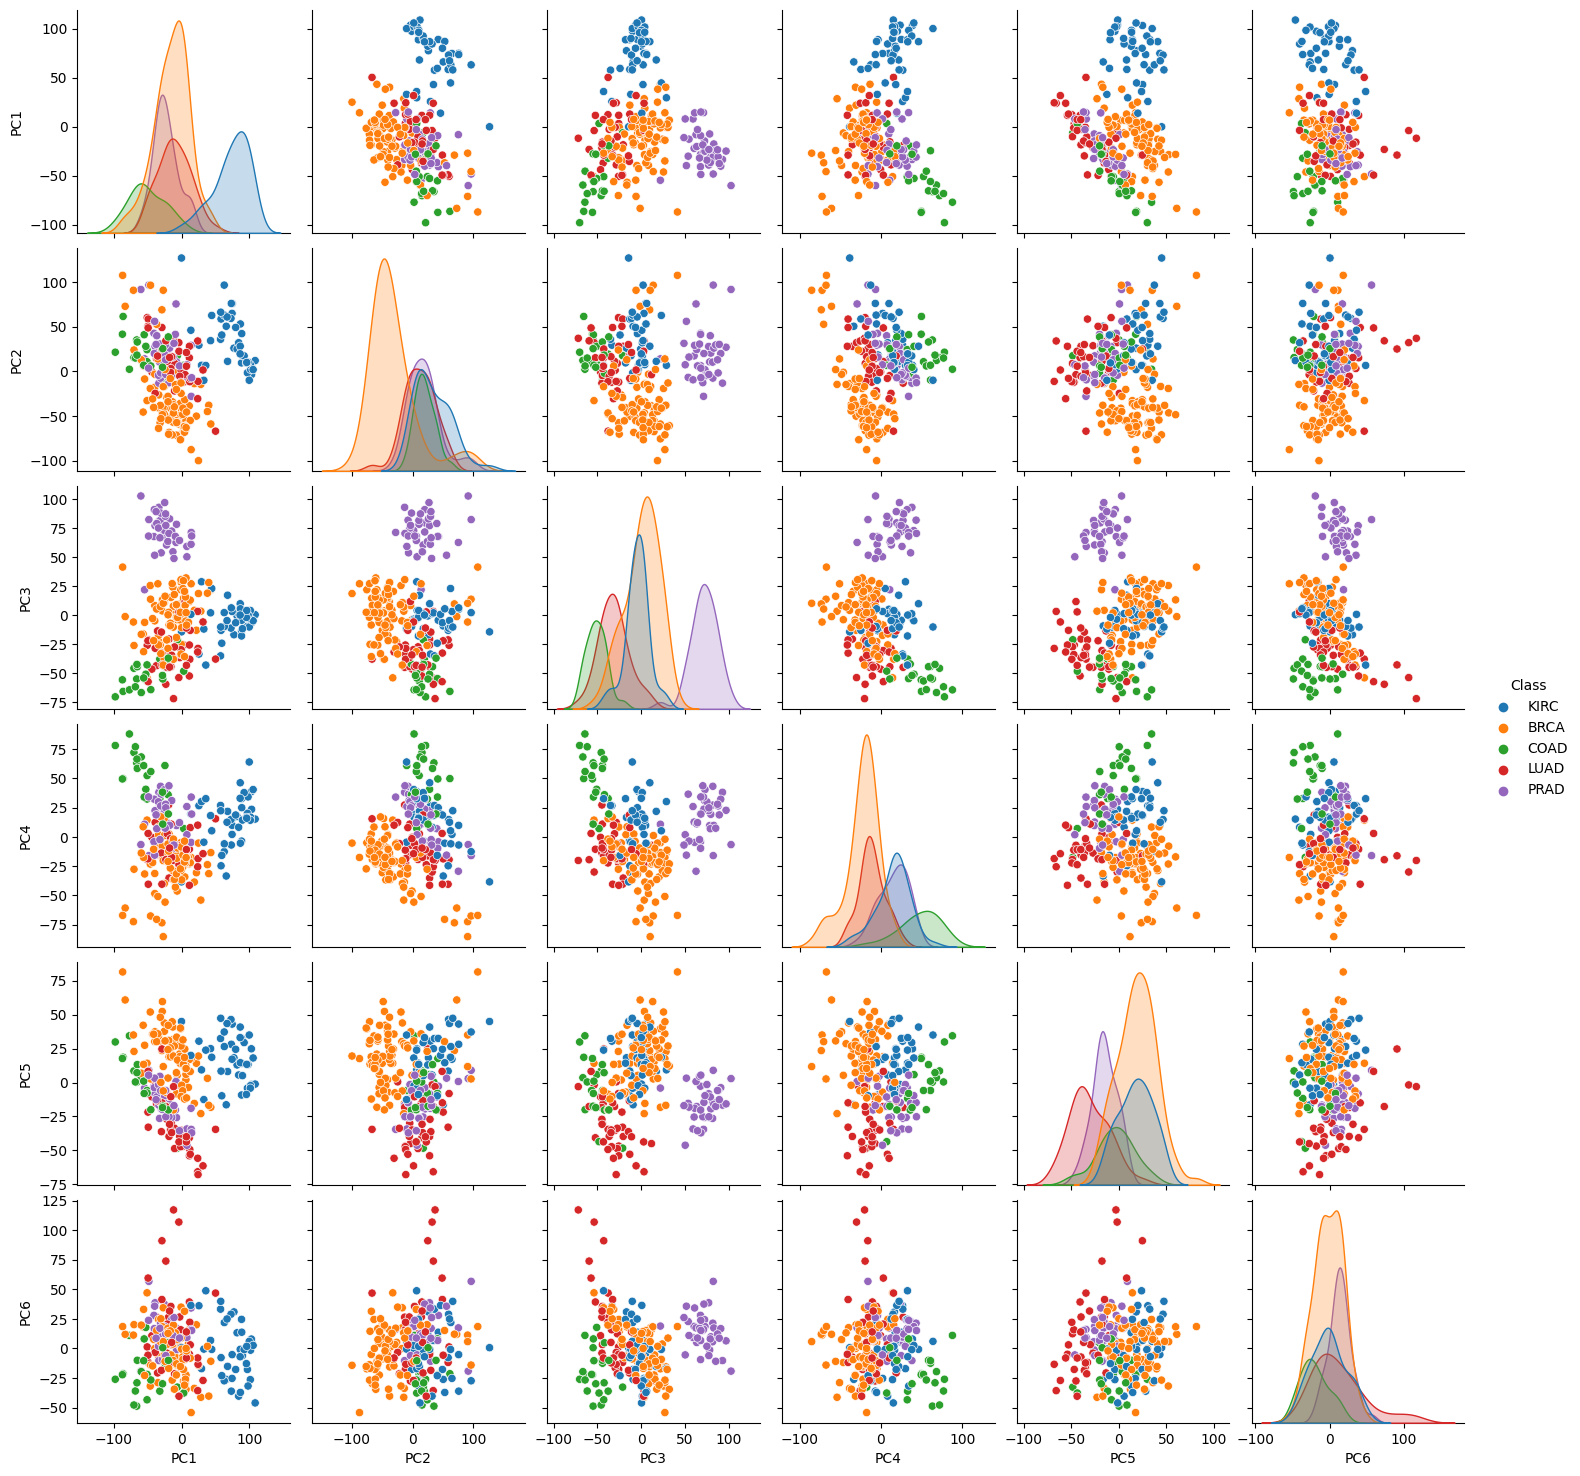

In [106]:
#note: this code may take a long time to run

#we can also look at many PCs at a time:
sns.pairplot(pca_df, 
             hue="Class",
             vars = pca_df.columns[0:6])

## ¡ Explore some of these principal components

### ¡ Plot some PCs which may show a difference between two tumor types

"pca_df" has samples as rows and PCs as columns. Each cell is the value of the PC for a sample

In [107]:
# plot_PCs(pca_df, PC_x, PC_y)

### ¡ What are the most important genes within these PCs? Plot these for both PCs

"loading" has PCs as columns and gene names as rows. Each cell is a "weight:" how much a given gene contributes to that PCs' overall value

In [108]:
# PCloadings = loading.loc[your_PC_here]
# plot_PC_loadings(PCloadings, label=your_PC_here)

### ¡ Gather some of the most important genes (5-20 genes) and plot them as a heatmap

"test_byclass" has tumor Class as rows and gene name as columns. Each cell corresponds to the number of counts.

In [109]:
# top_genes = list(PCloadings.sort_values()[-20:].index)
# bottom_genes = list(PCloadings.sort_values()[:20].index)
# top_and_bottom_genes = top_genes + bottom_genes


# sns.heatmap(test_byclass[top_and_bottom_genes])

## ¡ Which genes stand out the most in your heatmap? Plot these (2 at a time)

"test_byclass" has tumor Class as rows and gene name as columns. Each cell corresponds to the number of counts.

In [110]:
# plot_2_genes(test_byclass, gene1, gene2)

### ¡ Look up these genes. What is their biological role? Can you see a link to Cancer?

Some websites that may be helpful:
- GeneCards
    - https://www.genecards.org
    - "a searchable, integrative database that provides comprehensive, user-friendly information on all annotated and predicted human genes"
- GTEx
    - https://gtexportal.org/home/
    - "a comprehensive public resource for researchers studying tissue and cell-specific gene expression and regulation across individuals and development"
- The Human Protein Atlas
    - https://www.proteinatlas.org
    - has a cancer section for each gene, which may helpful

# § Evaluating one of the Classifiers

### § Import the classifier

In [117]:
SVM_all = load_object(files_dict["SVM_all_scaled-counts"])

## ! Success Metric: Accuracy

let's look at each step so that we understand what we are evaluating. Use SVM_all as an example

In [118]:
model = SVM_all
type(model)

sklearn.svm._classes.SVC

https://scikit-learn.org/stable/modules/svm.html

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

In [119]:
#This model was trained on all scaled counts. We can represent this as "x":
x = test_scaled

#note that other models may be trained on other, manipulated data.

print(x.shape)
x

(241, 20531)


array([[ 5.32790035, -0.95201026, -0.24294578, ...,  0.07263355,
         0.34484592, -0.25931168],
       [-0.19450727,  0.76176749,  1.22329621, ..., -0.3771546 ,
         0.5700329 , -0.25931168],
       [-0.19450727, -0.51500189, -0.30048008, ...,  0.33759662,
        -0.13332658, -0.25931168],
       ...,
       [-0.19450727, -0.60482984,  0.68197485, ..., -0.08176408,
        -0.91990212,  1.98652387],
       [-0.19450727,  0.93811059,  1.13283308, ..., -0.42833995,
        -0.02792912, -0.25931168],
       [-0.19450727,  0.40663709, -0.11730855, ..., -0.37239216,
         1.80835534, -0.25931168]])

In [120]:
#and this is what the model will predict
y = test_labels
y

,Class
sample_698,KIRC
sample_498,BRCA
sample_278,KIRC
sample_619,BRCA
sample_353,COAD
...,...
sample_137,BRCA
sample_57,COAD
sample_403,LUAD
sample_140,BRCA


In [121]:
#we use this function to predict the class based on the test_data
prediction = SVM_all.predict(x)
#it takes in the counts data and then gives back a list of what each is predicted to be

In [122]:
print(prediction.shape)
prediction[:10]

(241,)


array(['KIRC', 'BRCA', 'KIRC', 'BRCA', 'COAD', 'BRCA', 'LUAD', 'LUAD',
       'BRCA', 'KIRC'], dtype=object)

In [123]:
#Let's manually compare the predictions to the real class.

#make a copy to not change the original
comp = test_labels.copy()
#change the column name to keep track of actual vs. predicted
comp.rename(columns={"Class" : "actual"}, inplace=True)
#add the predicted column (from the object we made above)
comp["predicted"] = prediction
comp

,actual,predicted
sample_698,KIRC,KIRC
sample_498,BRCA,BRCA
sample_278,KIRC,KIRC
sample_619,BRCA,BRCA
sample_353,COAD,COAD
...,...,...
sample_137,BRCA,BRCA
sample_57,COAD,COAD
sample_403,LUAD,LUAD
sample_140,BRCA,BRCA


from a first gance, it looks like it did pretty good!

In [124]:
accuracy = comp["actual"] == comp["predicted"]
accuracy

sample_698    True
sample_498    True
sample_278    True
sample_619    True
sample_353    True
              ... 
sample_137    True
sample_57     True
sample_403    True
sample_140    True
sample_660    True
Length: 241, dtype: bool

In [125]:
accuracy.value_counts()

True     232
False      9
Name: count, dtype: int64

In [126]:
n_T = accuracy.value_counts()[True]
n_F = accuracy.value_counts()[False]
percent_accurate = n_T / (n_T + n_F) * 100
print(f"With {n_T} right and {n_F} wrong, the accuracy is {percent_accurate:0.4} %")

With 232 right and 9 wrong, the accuracy is 96.27 %


Scikit also has a function which does this same thing:

In [127]:
accuracy_score(y, prediction)
#this is the same as what we calculated manually.
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

0.9626556016597511

### ø A function to get the accuracy score for a given model

In [128]:
#we can encapsulate all of these steps into a single function
def return_accuracy_score(model_or_pred, x, y):
    
    #first, make the prediction
    
    #note this is a computationally expensive step
    #therefore, we will provide the option to pass in probability OR the model
    if type(model_or_pred) is np.ndarray: #this means it is a probability
        prediction = model_or_pred #so just use what was passed in
    else: #if it is not an numpy array, that means that this is a model
        prediction = model.predict(x) #so make the prediction here
    
    #get the accuracy of this prediction
    score = accuracy_score(y, prediction)
    
    #return this value
    return score

## ! Exploring prediction probabilities

In addition to looking at the predictions (which is what class the tumor is), we can also look at the probabilities. This shows us that the model has more confidence in some choices compared to others.

This allows us to use a more nuanced metric for evaluating how succesful a model is: the Reciever Operator Statistics (ROC)

In [129]:
probability = model.predict_proba(x)

In [130]:
print(probability.shape)
probability
#note that there are 241 samples and 5 different classes of tumor

(241, 5)


array([[6.95538440e-04, 1.77262800e-03, 9.93609991e-01, 2.27019220e-03,
        1.65165053e-03],
       [9.75218089e-01, 2.95233963e-03, 6.56385855e-03, 9.59079967e-03,
        5.67491279e-03],
       [1.01369236e-03, 1.74508647e-03, 9.92762759e-01, 2.01527624e-03,
        2.46318633e-03],
       ...,
       [1.04180792e-03, 6.30455188e-03, 3.46268083e-03, 9.86353014e-01,
        2.83794576e-03],
       [9.93791128e-01, 1.14421183e-03, 9.48346906e-04, 9.39187709e-04,
        3.17712515e-03],
       [4.48517538e-04, 1.49030701e-03, 1.82582079e-03, 1.43159860e-03,
        9.94803756e-01]])

In [131]:
# also note that, for each row, the sum of the values is roughly equal to one:
for i in range(5):
    print(f"row {i} sum: {sum(probability[i])}")

row 0 sum: 1.0000000000000002
row 1 sum: 0.9999999999999997
row 2 sum: 1.0000000000000002
row 3 sum: 1.0000000000000002
row 4 sum: 1.0000000000000002


In the probability matrix:
- each row corresponds to each sample #
- there are 5 columns, which correspond to the 5 tumor classes
- each cell represents the model's "confidence" or probability that this row (sample) is of this column (class)

For each row, the column with the highest probability becomes the "prediction" that we saw above.

In [132]:
#once again, let's compare this to the actual data and see if its confidence is well-placed.
classes = list(SVM_all.classes_)

for (i, c) in enumerate(classes):
    #iterate through the 5 columns with "enumerate"
    # "i" is an index and "c" is the 5 classes. You can see it in the print statement:
    print(f"{i} : {c}")
    
    #we need "i" to select the right column from the numpy array.
    #and we need "c" to use as the column label when we add it to the dataframe
    comp[c] = probability[:,i]
comp

0 : BRCA
1 : COAD
2 : KIRC
3 : LUAD
4 : PRAD


,actual,predicted,BRCA,COAD,KIRC,LUAD,PRAD
sample_698,KIRC,KIRC,0.000696,0.001773,0.993610,0.002270,0.001652
sample_498,BRCA,BRCA,0.975218,0.002952,0.006564,0.009591,0.005675
sample_278,KIRC,KIRC,0.001014,0.001745,0.992763,0.002015,0.002463
sample_619,BRCA,BRCA,0.972737,0.001701,0.004721,0.004719,0.016122
sample_353,COAD,COAD,0.002751,0.984468,0.003595,0.005655,0.003530
...,...,...,...,...,...,...,...
sample_137,BRCA,BRCA,0.988873,0.002668,0.001309,0.002640,0.004510
sample_57,COAD,COAD,0.005927,0.976540,0.003399,0.010524,0.003611
sample_403,LUAD,LUAD,0.001042,0.006305,0.003463,0.986353,0.002838
sample_140,BRCA,BRCA,0.993791,0.001144,0.000948,0.000939,0.003177


In [133]:
#and let's also add a confidence column
#this will take the highest % of all 5 columns, which shows how confident the model was in its choice

#make an empty list that we will populate in the for loop
confidence = []
for i in range(comp.shape[0]):
    #note that comp.shape returns (rows, columns), so this for loop is iterating through each row
    
    #first, get the row by slicing with iloc (the index locator)
    row = comp.iloc[i]
    #the "row" is a Series object. we want to get just the maximum of the values, 
    # but JUST of the columns which have the probabilites. remember these are in the "classes" list
    c = max(row[classes])
    #and then add it to the list
    confidence.append(c)
#since we went through every row, this list will have the same # of elements as rows.
#so we can add it to the dataframe as another column:
comp["confidence"] = confidence

#and let's add another column as to whether or not the model was accurate

accuracy = comp["actual"] == comp["predicted"]
#"accuracy" is a list of booleans (True/False) which represents whether the predicted was equal to the actual
#when comparing two columns, this is a row-wise operation. so "accuracy" can be added as a column.

#but eventually, we want to plot these and the Booleans would plot as 0 and 1
accuracy = [str(x) for x in accuracy] #therefore we change each element to a string
#note that python treats these as different things:
print(f"is \"True\" the same as True: {'True' == True}")


#finally let's add this as another column to the dataframe
comp["correct"] = accuracy

is "True" the same as True: False


In [134]:
#here is what the final matrix looks like:
comp

,actual,predicted,BRCA,COAD,KIRC,LUAD,PRAD,confidence,correct
sample_698,KIRC,KIRC,0.000696,0.001773,0.993610,0.002270,0.001652,0.993610,True
sample_498,BRCA,BRCA,0.975218,0.002952,0.006564,0.009591,0.005675,0.975218,True
sample_278,KIRC,KIRC,0.001014,0.001745,0.992763,0.002015,0.002463,0.992763,True
sample_619,BRCA,BRCA,0.972737,0.001701,0.004721,0.004719,0.016122,0.972737,True
sample_353,COAD,COAD,0.002751,0.984468,0.003595,0.005655,0.003530,0.984468,True
...,...,...,...,...,...,...,...,...,...
sample_137,BRCA,BRCA,0.988873,0.002668,0.001309,0.002640,0.004510,0.988873,True
sample_57,COAD,COAD,0.005927,0.976540,0.003399,0.010524,0.003611,0.976540,True
sample_403,LUAD,LUAD,0.001042,0.006305,0.003463,0.986353,0.002838,0.986353,True
sample_140,BRCA,BRCA,0.993791,0.001144,0.000948,0.000939,0.003177,0.993791,True


Text(0.5, 0, 'Correct prediciton?')

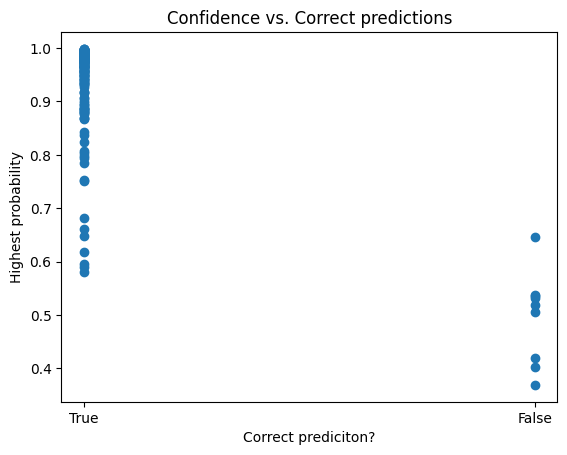

In [135]:
#Now we can see whether the highest confidence scores were the most accurate:
fig, ax = plt.subplots()

ax.scatter(comp["correct"], comp["confidence"])
ax.set_title("Confidence vs. Correct predictions")
ax.set_ylabel("Highest probability")
ax.set_xlabel("Correct prediciton?")

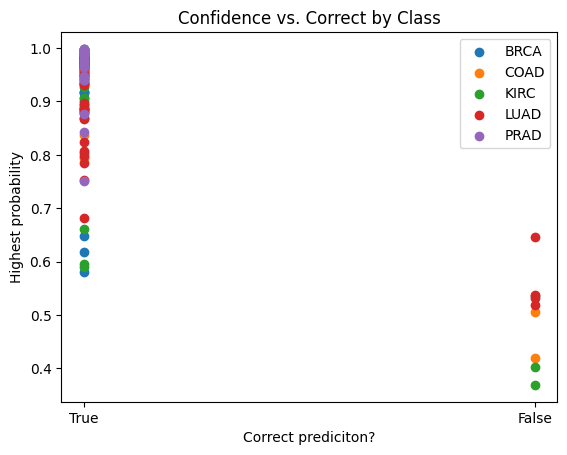

In [136]:
#And we can even explore whether this was different by class:
fig, ax = plt.subplots()

for c in classes:
    comp_ = comp[comp["actual"] == c]
    ax.scatter(comp_["correct"], comp_["confidence"], label = c)
    
ax.set_title("Confidence vs. Correct by Class")
ax.set_ylabel("Highest probability")
ax.set_xlabel("Correct prediciton?")
ax.legend()

The ROC area under the curve (ROC AUC) score attempts to encapsulate this in a single metric. We won't go into the intricacies, but we can treat it as a summary of this plot

### ø Make a function to generate this same plot

In [137]:
#let's make a function for plotting this more easily
def make_comp_df(model, probability, y):
    #build the dataframe that shows the comparison
    comp = y.copy()
    comp.rename(columns={"Class" : "actual"}, inplace=True)
    
    #add the classes' probabilities to the dataframe
    classes = list(model.classes_)
    for (i, c) in enumerate(classes):
        #add this class's column to the dataframe "comp", which we constructed above
        comp[c] = probability[:,i]
        
    #and let's also add a confidence column
    #this will take the highest % of all 5 columns, which shows how confident the model was in its choice
    confidence = []
    predicted = []
    for i in range(comp.shape[0]):
        c = max(comp.iloc[i][classes].values)
        confidence.append(c)
        predicted.append(comp[classes].iloc[i].idxmax())
    comp["confidence"] = confidence
    comp["predicted"] = predicted

    #and let's add another column as to whether or not the model was accurate
    accuracy = comp["actual"] == comp["predicted"]
    accuracy = [str(x) for x in accuracy] #we want these as strings so they do not plot as just 0 and 1
    comp["correct"] = accuracy
    
    return comp

def plot_confidence(model, x, y,
                   probability = None,
                   ax = None,
                   title = "title"):
    
    #this time, we need the model object
    #however, the user can still pass in the "probability" if they choose to do so
    if probability is None: #if not, we can calculate it here
        probability = model.predict_proba(x)
        
        
    #get the dataframe that shows the comparison
    comp = make_comp_df(model, probability, y)
    
    
    #again, the user can pass in an axis or leave it blank
    if ax is None:
        fig, ax = plt.subplots()

    classes = list(model.classes_)
    for c in classes:
        comp_ = comp[comp["actual"] == c]
        ax.scatter(comp_["correct"], comp_["confidence"], label = c)

    ax.set_title(title)
    ax.set_ylabel("Highest probability")
    ax.set_xlabel("Correct prediciton?")
    ax.legend()

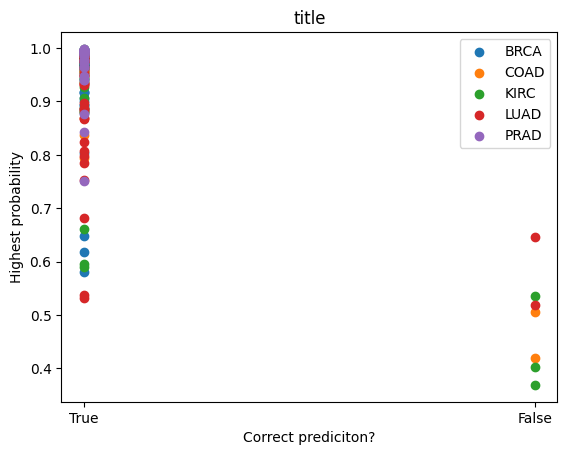

In [138]:
#test if the function works
plot_confidence(model, x, y)

## ø Success Metric: ROC area under the curve

You do not have to worry about the specific steps in this part, and can simply use the function. If you have the time, you can come back to this and see what each step is doing.

In [139]:
def return_ROC_AUC_score(model_or_prob, x, y):
    #first get the probabilities
    
    
    #note this is a computationally expensive step
    #therefore, we will provide the option to pass in probability OR the model
    if type(model_or_prob) is np.ndarray: #this means it is a probability
        probability = model_or_prob #so just use what was passed in
    else: #if it is not an numpy array, that means that this is a model
        probability = model.predict_proba(x)
    
    #in order to do an ROC score test, we have to change y_train into a binarized matrix
    lb = preprocessing.LabelBinarizer()
    lb.fit(y)
    binarized = lb.transform(y)
    
    #now calculate the score
    score = roc_auc_score(binarized, probability,
                              multi_class = "ovr" #one vs. the rest
                              )
    
    return score

In [140]:
# #this function works if we pass in the model

# score = return_ROC_AUC_score(model, x, y)
# print(f"ROC AUC score: {score:.4}")

# #output:
# #ROC AUC score: 0.9994

In [141]:
# #and it also works if we make the probaility and pass that in

# probability = model.predict_proba(x)
# score = return_ROC_AUC_score(probability, x, y)
# print(f"ROC AUC score: {score:.4}")

# #output:
# #ROC AUC score: 0.9994

# ¡ Evaluating all of the Classifiers

Each classifier was trained on the same training data. However, different manipulations were done before training. Therefore, we have to make those same manipulations on the testing data in order to accurately test the model. 

Remember the steps that we have done:
- test [Pandas Dataframe], raw data. samples as rows x genes as columns.
- test_scaled [numpy array], scaled data. samples as rows x genes as columns.
- test_pca [numpy array], PCA on the scaled data. samples as rows x PCs as columns

Here is an overview of each model and what the manipulations that were done to the data.
- SVM_all-scaled-counts.pkl
    - trained on All scaled counts
- SVM_all_unscaled-counts.pkl
    - trained on all unscaled counts
- SVM_2k-random_scaled-counts.pkl
    - trained on the last 2,000 genes (which are random... but not truly)
- SVM_200-random_scaled-counts.pkl
    - trained on the first 200 genes
- SVM_20-random_scaled-counts.pkl
    - trained on genes 10,000 to 10,020
- SVM_all_pca.pkl
    - trained on all PCs
- SVM_top5_pca.pkl
    - trained on the top 5 PCs
- SVM_bottom5_pca.pkl
    - trained on the bottom 5 PCs
- SVM_bottom500_pca.pkl
    - trained on the bottom 500 PCs

In [142]:
y = test_labels #this will be the same for all of the models

let's make a function to do all of the steps at once

make sure that you know what is happening in EACH and EVERY step!
- you don't have to understand the inside workings of the functions that we are calling
    - but we did build them mostly with the code we ran together in previous sections
- what is the data type of each of the following things, and what information do they hold?
    - model
    - pred 
    - prob
    - accuracy
    - ROC_AUC

In [143]:
#make a function to do all of these steps at once

#make sure you know what is happening in EACH and EVERY step!
#you don't have to understand the inside workings functions that we are calling

#but definitely 
def summarize_model(model, x, y, title):
    """
    This function summarizes the success metrics for a classifier.
    Input:
        model [sklearn.svm._classes.SVC] trained model to be tested
        x [numpy.ndarray] (samples, features) test data
        y [pandas.core.frame.DataFrame] (samples, 1) actual class identities for each sample
        title [str] name of model for print statements and plot titles
    Returns:
        (accuracy, ROC_AUC)
        accuracy [float] accuracy score from sklearn's accuracy_score function
        ROC_AUC [float] ROC_AUC score from sklearn's roc_auc_score function
    """
    
    #make the predictions and probabilitys
    #this is the step that takes the most computation
    pred = model.predict(x)
    prob = model.predict_proba(x)
    
    #print out the metrics and make the plot
    plot_confidence(model, x, y, title=title, probability = prob)

    accuracy = return_accuracy_score(pred, x, y)
    print(f"{title} Accuracy: {accuracy:.6}")
    ROC_AUC = return_ROC_AUC_score(prob, x, y)
    print(f"{title} ROC AUC score: {ROC_AUC:.6}")
    
    return (accuracy, ROC_AUC)

In [144]:
#make a dictionary to keep track of the results
acc_ROC = {}

#we will populate it like this:
# acc_ROC["model_name"] = summarize_model()

### ! SVM All

This one is pre-filled for the same model we evaluated stepwise above. For the rest, you will have to do it yourselves.

In [147]:
name_all = "SVM_all_scaled-counts"
SVM_all = load_object(files_dict[name_all])

In [148]:
#first wrangle the data in the same way that it was prepared for training the model
#in this case we have already prepared it
x_all = test_scaled

SVM_all_scaled-counts Accuracy: 0.962656
SVM_all_scaled-counts ROC AUC score: 0.999414


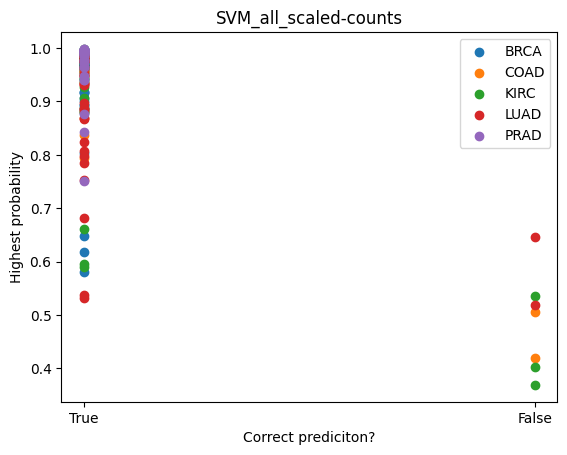

In [149]:
acc_ROC[name_all] = summarize_model(SVM_all, x_all, y, title=name_all)

Note that the data for SVM_all is all of the scaled counts: x = test_scaled. This is only for this models. All of the other models you are evaluating will have been trained on slightly different manipulated data. 

You will have to do these same manipulations on the test data before giving it to the model to make its predictions. The information above gives you everything that you need to know about how the training data was manipulated.

Here are some resources and functions that may be helpful (but not all of them):
- The code we have used above has some useful examples
- In the figures folder, there are a few cheat sheets:
    - numpy common manipulations and functions
    - pandas common manipulations and functions
- Indexing on numpy arrays: 
    - https://numpy.org/doc/stable/user/basics.indexing.html
- Indexing on Pandas dataframes:
    - https://pandas.pydata.org/docs/user_guide/indexing.html
- Panda's function to convert to numpy:
    - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy
- Python functions for exploring objects:
    - type(obj)
    - obj.shape
    - obj.head() (only for Pandas objects)

In [151]:
#if you need a hint, you can use the "hints" dictionary and pass in the name as a key.
print(hints["SVM all scaled counts"])

#this is what we used above as the "x_all" for the "SVM_all":

test_scaled


## ¡ SVM unscaled

In [154]:
name_unscaled = "SVM_all_unscaled-counts"
SVM_unscaled = load_object(files_dict[name_unscaled])

In [155]:
# x_unscaled = 
# acc_ROC[name_unscaled] = summarize_model(SVM_unscaled, x_unscaled, y, title=name_unscaled)

## ¡ SVM 2k random

In [156]:
name_2krand = "SVM_2k-random_scaled-counts"
SVM_2krand = load_object(files_dict[name_2krand])

In [157]:
# x_2krand = 
# acc_ROC[name_2krand] = summarize_model(SVM_2krand, x_2krand, y, title=name_2krand)

## ¡ SVM 200 random

In [158]:
name_200rand = "SVM_200-random_scaled-counts"
SVM_200rand = load_object(files_dict[name_200rand])

In [159]:
# x_200rand = 
# acc_ROC[name_200rand] = summarize_model(SVM_200rand, x_200rand, y, title=name_200rand)

## ¡ SVM 20 random

In [172]:
name_20rand = "SVM_20-random_scaled-counts"
SVM_20rand = load_object(files_dict[name_20rand])

In [175]:
# x_20rand = 
# acc_ROC[name_20rand] = summarize_model(SVM_200rand, x_200rand, y, title=name_20rand)

## ¡ SVM all PCA

In [163]:
name_all_PCA = "SVM_all_pca"
SVM_all_PCA = load_object(files_dict[name_all_PCA])

In [164]:
# x_all_PCA = 
# acc_ROC[name_all_PCA] = summarize_model(SVM_all_PCA, x_all_PCA, y, title=name_all_PCA)

## ¡ SVM top 5 PCA

In [165]:
name_top5_PCA = "SVM_top5_pca"
SVM_top5_PCA = load_object(files_dict[name_top5_PCA])

In [166]:
# x_top5_PCA = 
# acc_ROC[name_top5_PCA] = summarize_model(SVM_top5_PCA, x_top5_PCA, y, title=name_top5_PCA)

## ¡ SVM bottom 5 PCA

In [167]:
name_bottom5_PCA = "SVM_bottom5_pca"
SVM_bottom5_PCA = load_object(files_dict[name_bottom5_PCA])

In [168]:
# x_bottom5_PCA = 
# acc_ROC[name_bottom5_PCA] = summarize_model(SVM_bottom5_PCA, x_bottom5_PCA, y, title=name_bottom5_PCA)

## ¡ SVM bottom 500 PCA

In [169]:
name_bottom500_PCA = "SVM_bottom500_pca"
SVM_bottom500_PCA = load_object(files_dict[name_bottom500_PCA])

In [170]:
# x_bottom500_PCA = 
# acc_ROC[name_bottom500_PCA] = summarize_model(SVM_bottom500_PCA, x_bottom500_PCA, y, title=name_bottom500_PCA)

## Compare all of the models

In [176]:
# acc_ROC

# #what do you notice?